In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

#import torch
import torch.nn as nn
#from torch.utils.data import  TensorDataset, DataLoader

from eval_functions import auc_and_fpr_recall, calc_outputs_test, train, visualize

sys.path.append(os.path.abspath('..'))
from config_mounir import FarOODFramework
from data import get_y, get_dataloader

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
import torch 
torch.cuda.is_available()

True

# Préparation des données

In [3]:
framework = FarOODFramework()
dataset_id, dataset_ood = framework.get_confs("id", "ash"), framework.get_confs("ood","ash")
X = np.vstack([dataset_id, dataset_ood])
Y = get_y(dataset_id, dataset_ood)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                X, Y, stratify=Y, test_size=0.2, random_state=42)

data = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [ ]:
# with open("data_vf.pkl", 'wb') as f:
#     pickle.dump(data, f)

# Chargement des données

In [6]:
with open('data_vf.pkl', 'rb') as f:
    data = pickle.load(f)

In [12]:
train_dataloader = get_dataloader(data["X_train"], data["y_train"], batch_size=32) 
test_dataloader = get_dataloader(data["X_test"], data["y_test"], batch_size=32) 

5652 elements (array([0., 1.], dtype=float32), array([ 674, 4978]))
1413 elements (array([0., 1.], dtype=float32), array([ 169, 1244]))


# Modèle

In [13]:
# Calcul des poids des classes
unique_values, counts = np.unique(data["y_train"], return_counts=True) ### Entrainement avec pondération
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.13539574126155082

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow
output_dim = 1
model = nn.Linear(input_dim, output_dim)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes

lr=1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 50

/tmp/ipykernel_1715093/973832275.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes


# Entrainement

cpu
accuracy train:  0.8793079095371699


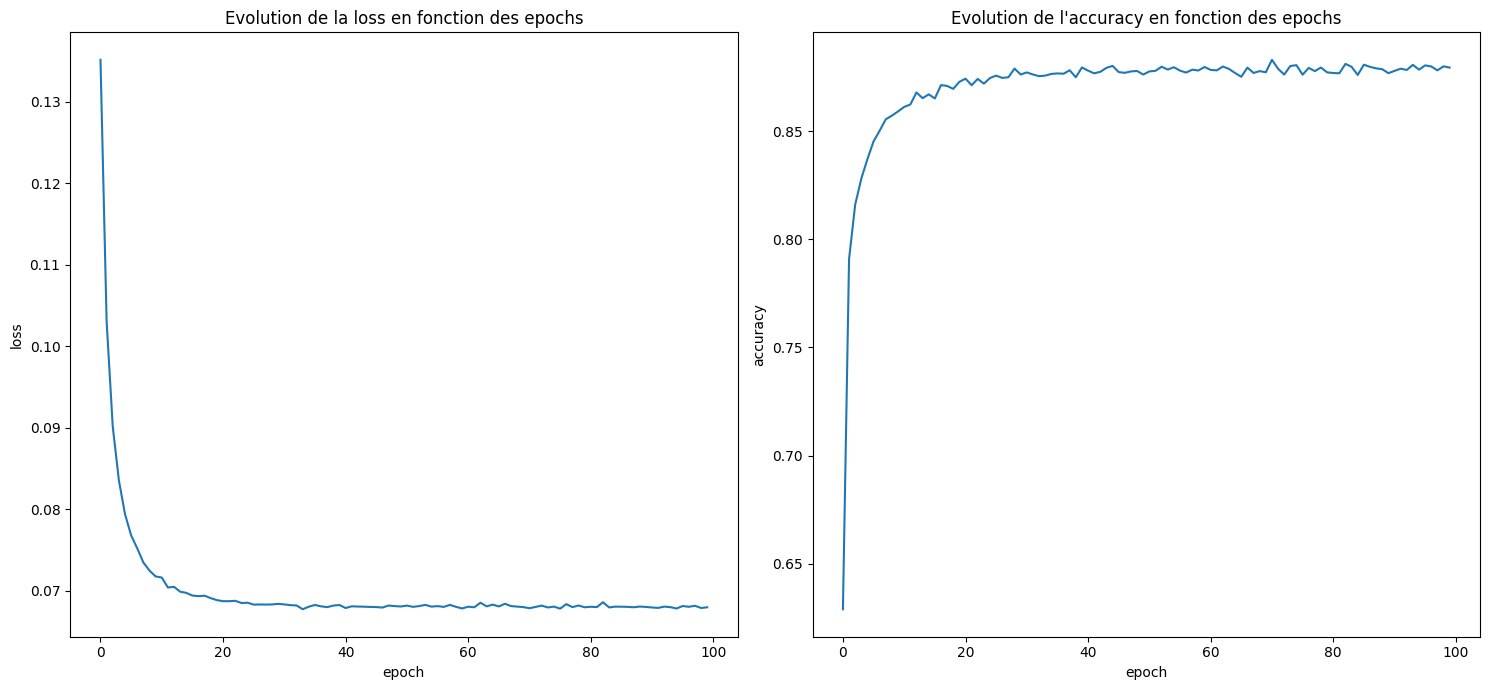

In [24]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs=100)
visualize(plot_loss, plot_acc)

In [25]:
torch.save(model.state_dict(), "model_vf.pth")

In [26]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-8.2436,  4.2558, -5.5319, -1.8816]])
bias
tensor([8.7740])


# Tests

### Séparabilité

In [ ]:
outputs_test = calc_outputs_test(model, test_dataloader)

# with open("outputs_test_vf.pkl", 'wb') as f:
#     pickle.dump(outputs_test, f)

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


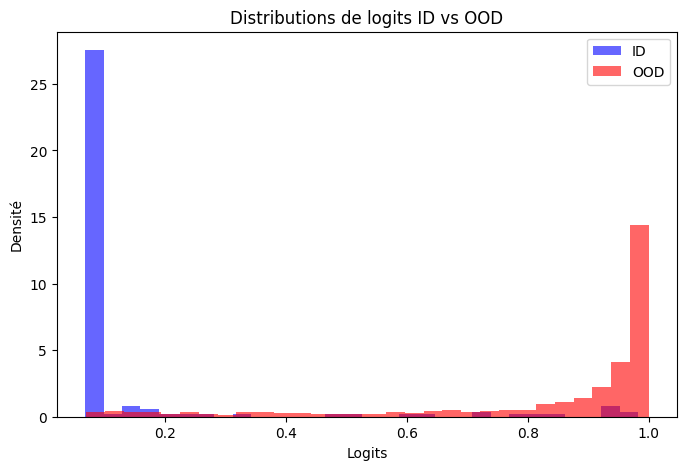

In [ ]:
with open("outputs_test_vf.pkl", 'rb') as f:
    outputs_test = pickle.load(f)

plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


### AUC & FPR

In [34]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.9687208660743165, 0.10650887573964497)

## Corrélation

In [29]:
def calc_correlations(framework, layer_proc, poids):
    """
    ordre poids: sans, tout, video, flow, [audio]
    """
    poids = poids[1:]
    # id
    conf_sans, *confs_avec = framework.get_confs("id", layer_proc).transpose()
    diffs_id = [np.round(calc_perturbations(conf_sans, conf), 4) for conf in confs_avec]
    #diffs_far_ood_id = [labels[0], diff_tout, diff_video, diff_flow, 0] # 0 pour l'audio

    #ood
    conf_sans, *confs_avec = framework.get_confs("ood", layer_proc).transpose()
    if framework.ood_mode != "vfa":
        #print(type(confs_avec[0]))
        #print([np.round(calc_perturbations(conf_sans, conf), 4) for conf in confs_avec])
        diffs_ood = [np.round(calc_perturbations(conf_sans, conf), 4) for conf in confs_avec]
        df = pd.DataFrame([["poids_"+framework.ood_mode]+poids, ["perturbation_"+framework.ood_mode+"_id"]+diffs_id,  ["perturbation_"+framework.ood_mode+"_ood"]+diffs_ood], columns = ["config", 'tout', 'video', 'flow'])
    else:
        diffs_ood = [np.round(calc_perturbations(conf_sans, conf), 4) for conf in confs_avec]    
        df = pd.DataFrame([["poids_"+framework.ood_mode]+poids, ["perturbation_"+framework.ood_mode+"_id"]+diffs_id,  ["perturbation_"+framework.ood_mode+"_ood"]+diffs_ood], columns = ["config", 'tout', 'video', 'flow', 'audio'])

    correlation_id = np.corrcoef(poids, diffs_id)[0,1]
    correlation_ood = np.corrcoef(poids, diffs_ood)[0,1]
    #print(f"{correlation_far_id=}, {correlation_far_ood=}")
    
    return df, correlation_id, correlation_ood

In [30]:
df, correlation_id, correlation_ood = calc_correlations(FarOODFramework(), "ash", [-8.2436,  4.2558, -5.5319, -1.8816])
print("Correlation ID : ", correlation_id)
print("Correlation OOD : ", correlation_ood)
df

Correlation ID :  -0.31657449514490404
Correlation OOD :  -0.9157568159723631


,config,tout,video,flow
0,poids_far_ood,4.2558,-5.5319,-1.8816
1,perturbation_far_ood_id,0.0088,0.0102,0.0071
2,perturbation_far_ood_ood,0.1374,0.1613,0.1623


# Modèle 2 Couches

In [36]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 100

/tmp/ipykernel_1715093/3576247373.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes


cpu
accuracy train:  0.932026836158192


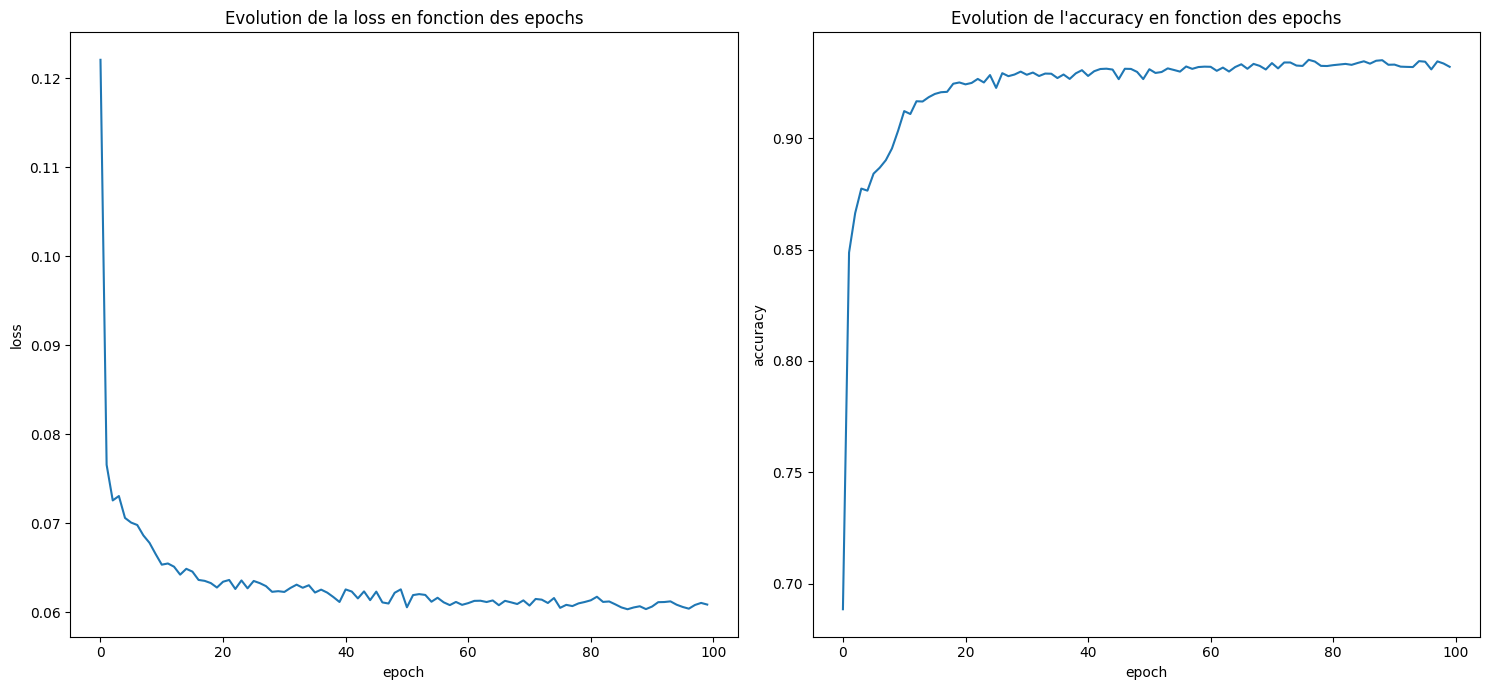

In [37]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [38]:
torch.save(model.state_dict(), "model_near_2c.pth")

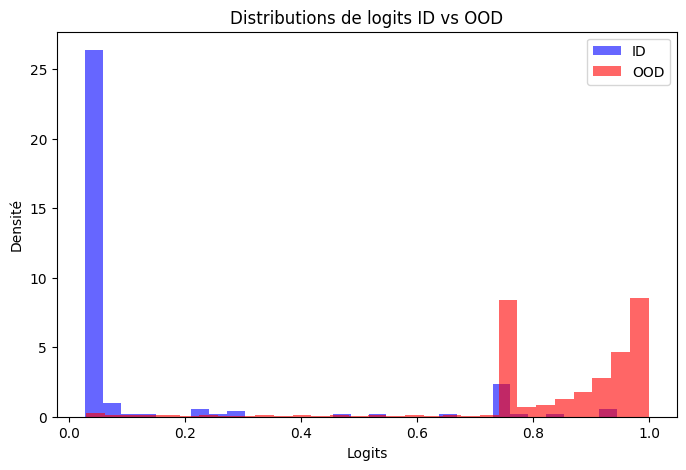

In [39]:
outputs_test = calc_outputs_test(model, test_dataloader)
plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


In [40]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.9679645731463689, 0.11242603550295859)